In [1]:
import numpy as np 
import matplotlib.pyplot as plt

A = 1 
alpha = 0.1 
gamma = 0.5
epsilon = 0.01
iapp = 0.5 
v0 = 0.0
w0 = 0.0
d = 0.01 #difusao


h=0.0001 #passos de tempo
delta_x = 0.01 #passo espacial

xf = 1.0
tf = 2 #tempo final

t = np.arange(0, tf + h, h)
x = np.arange(0, xf + delta_x, delta_x)

iapp_vet = np.zeros(len(t))
iapp_vet[(t >= 0.0) & (t <= 0.2)] = 0.5    


In [2]:
def I_ion(v,w):
    return (1/epsilon)*(A*v*(alpha - v)*(v - 1)) - w - w0 

def g(v,w):
    return v - gamma*w


V = np.zeros((len(t), len(x))) 
W = np.zeros((len(t), len(x)))


#condicoes iniciais
V[0, :] = v0
W[0, :] = w0

for i in range(len(t)-1):
    for j in range(1, len(x)-1):

        if x[j] <= 0.1:
            estimulo = iapp_vet[i]
        else:            
            estimulo = 0
       
        dvdt = d*(V[i,j+1] - 2*V[i,j] +V[i,j-1])/delta_x**2 + I_ion(V[i,j], W[i,j]) + estimulo
        dwdt = g(V[i,j], W[i,j])

        V[i+1,j] = V[i,j] + dvdt * h
        W[i+1,j] = W[i,j] + dwdt * h

    #condicoes de contorno
    V[i+1,0] = V[i+1,1]
    V[i+1,-1] = V[i+1,-2]
    W[i+1,0] = W[i,0] + dwdt * h
    W[i+1,-1] = W[i,-1] + dwdt * h



0
1000
5000
20000


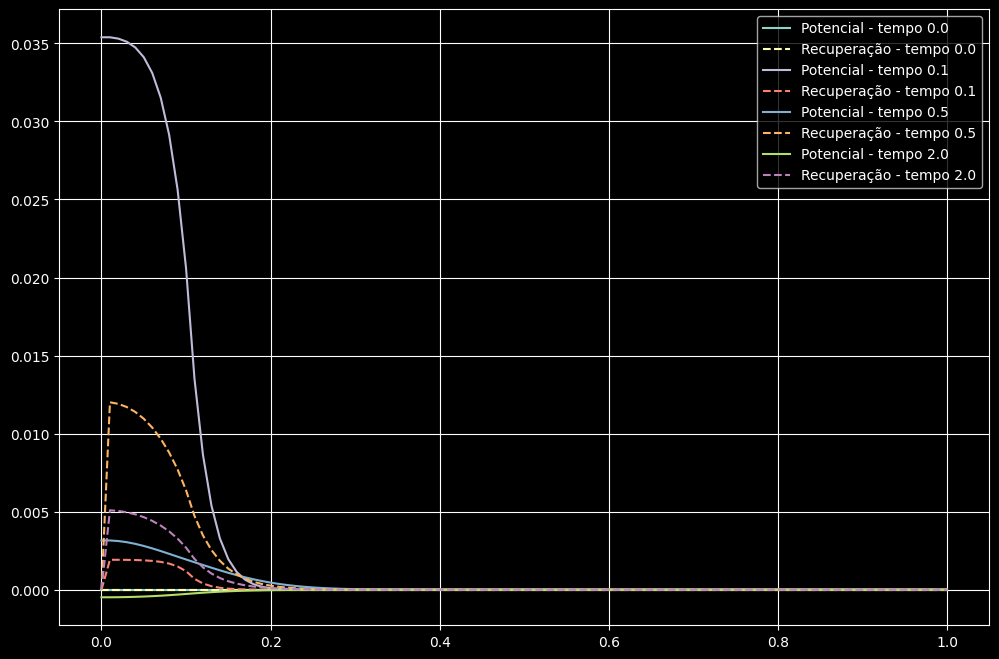

[[ 0.00000000e+00  0.00000000e+00  0.00000000e+00 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 5.00000000e-05  5.00000000e-05  5.00000000e-05 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 [ 9.99500275e-05  9.99500275e-05  9.99500275e-05 ...  0.00000000e+00
   0.00000000e+00  0.00000000e+00]
 ...
 [-4.87437528e-04 -4.87437528e-04 -4.82696622e-04 ... -3.24942700e-15
  -2.82208626e-15 -2.82208626e-15]
 [-4.87408628e-04 -4.87408628e-04 -4.82668002e-04 ... -3.25134703e-15
  -2.82390102e-15 -2.82390102e-15]
 [-4.87379730e-04 -4.87379730e-04 -4.82639383e-04 ... -3.25326617e-15
  -2.82571497e-15 -2.82571497e-15]]


In [3]:

t_plot = [0.0, 0.1, 0.5, 2.0]
plt.figure(figsize=(12,8))
for t in t_plot:
    plt.plot(x,V[int(t/h),:], label = 'Potencial - tempo {}'.format(t))
    plt.plot(x,W[int(t/h),:], label = 'Recuperação - tempo {}'.format(t), linestyle='--')
    print(int(t/h))
plt.legend()
plt.grid(True)
plt.show()

print(V)